# FASE 3: Análisis Comparativo TASS vs Sarcasmo

**Objetivo**: Comparar el rendimiento de los modelos BETO y XLM-RoBERTa entre las tareas de:
- **TASS**: Clasificación de sentimiento (3 clases: N, NEU, P)
- **Sarcasmo**: Clasificación de sarcasmo (2 clases: SARCASMO, NO_SARCASMO)

## Preguntas de investigación:
1. ¿Cómo afecta el número de clases (2 vs 3) al rendimiento?
2. ¿Qué modelo es más robusto entre tareas?
3. ¿Qué tarea es más difícil para los modelos?
4. ¿Cómo se comparan las métricas de F1 y Accuracy entre tareas?

## 1. Cargar Resultados

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Rutas de resultados
TASS_RESULTS_DIR = Path('../resultados/fase1_tass')
SARCASMO_RESULTS_DIR = Path('../resultados/fase2_sarcasmo')

# Cargar resultados detallados
with open(TASS_RESULTS_DIR / 'tass_detailed_results.json', 'r', encoding='utf-8') as f:
    tass_results = json.load(f)

with open(SARCASMO_RESULTS_DIR / 'sarcasmo_detailed_results.json', 'r', encoding='utf-8') as f:
    sarcasmo_results = json.load(f)

# Cargar comparaciones
tass_comparison = pd.read_csv(TASS_RESULTS_DIR / 'tass_results_comparison.csv')
sarcasmo_comparison = pd.read_csv(SARCASMO_RESULTS_DIR / 'sarcasmo_results_comparison.csv')

# Inferir número de clases
# TASS: estructura plana {beto: {...}, xlm_roberta: {...}}
# Sarcasmo: estructura anidada {models: {beto: {...}, xlm_roberta: {...}}, num_classes: 2}
if 'num_classes' in tass_results:
    tass_num_classes = tass_results['num_classes']
else:
    tass_num_classes = len(set(tass_results['beto']['predictions']))

if 'num_classes' in sarcasmo_results:
    sarcasmo_num_classes = sarcasmo_results['num_classes']
else:
    sarcasmo_num_classes = len(set(sarcasmo_results['models']['beto']['predictions']))

print("Resultados cargados correctamente")
print(f"\nTASS - Clases: {tass_num_classes}")
print(f"Sarcasmo - Clases: {sarcasmo_num_classes}")

Resultados cargados correctamente

TASS - Clases: 3
Sarcasmo - Clases: 2


## 2. Tabla Comparativa General

In [3]:
# Crear tabla comparativa unificada
comparison_data = []

# Normalizar acceso a resultados (TASS tiene estructura plana, Sarcasmo anidada)
def get_model_results(results, model_key, alt_key=None):
    """Obtiene resultados de modelo manejando ambas estructuras."""
    if 'models' in results:
        return results['models'][model_key]
    # Intentar con clave alternativa si existe (ej: xlmr vs xlm_roberta)
    if alt_key and alt_key in results:
        return results[alt_key]
    return results[model_key]

# TASS - BETO
tass_beto = get_model_results(tass_results, 'beto')
comparison_data.append({
    'Tarea': 'TASS (Sentimiento)',
    'Modelo': 'BETO',
    'Num_Clases': tass_num_classes,
    'Test_Accuracy': tass_beto['test_accuracy'],
    'Test_F1': tass_beto['test_f1'],
    'Test_Loss': tass_beto.get('test_loss', 'N/A'),
    'Train_Time_s': tass_beto.get('train_runtime', 'N/A')
})

# TASS - XLM-RoBERTa (usar 'xlmr' como clave alternativa)
tass_xlmr = get_model_results(tass_results, 'xlm_roberta', 'xlmr')
comparison_data.append({
    'Tarea': 'TASS (Sentimiento)',
    'Modelo': 'XLM-RoBERTa',
    'Num_Clases': tass_num_classes,
    'Test_Accuracy': tass_xlmr['test_accuracy'],
    'Test_F1': tass_xlmr['test_f1'],
    'Test_Loss': tass_xlmr.get('test_loss', 'N/A'),
    'Train_Time_s': tass_xlmr.get('train_runtime', 'N/A')
})

# Sarcasmo - BETO
sarcasmo_beto = get_model_results(sarcasmo_results, 'beto')
comparison_data.append({
    'Tarea': 'Sarcasmo',
    'Modelo': 'BETO',
    'Num_Clases': sarcasmo_num_classes,
    'Test_Accuracy': sarcasmo_beto['test']['accuracy'],
    'Test_F1': sarcasmo_beto['test']['f1'],
    'Test_Loss': sarcasmo_beto['test']['loss'],
    'Train_Time_s': sarcasmo_beto['train']['runtime']
})

# Sarcasmo - XLM-RoBERTa
sarcasmo_xlmr = get_model_results(sarcasmo_results, 'xlm_roberta')
comparison_data.append({
    'Tarea': 'Sarcasmo',
    'Modelo': 'XLM-RoBERTa',
    'Num_Clases': sarcasmo_num_classes,
    'Test_Accuracy': sarcasmo_xlmr['test']['accuracy'],
    'Test_F1': sarcasmo_xlmr['test']['f1'],
    'Test_Loss': sarcasmo_xlmr['test']['loss'],
    'Train_Time_s': sarcasmo_xlmr['train']['runtime']
})

df_comparison = pd.DataFrame(comparison_data)

print("Comparación General de Modelos")
print("-" * 80)
print(df_comparison.to_string(index=False))
print("-" * 80)

# Guardar tabla
df_comparison.to_csv('../resultados/fase3_comparativo/comparacion_general.csv', index=False)
print("\nTabla guardada en: resultados/fase3_comparativo/comparacion_general.csv")

Comparación General de Modelos
--------------------------------------------------------------------------------
             Tarea      Modelo  Num_Clases  Test_Accuracy  Test_F1 Test_Loss Train_Time_s
TASS (Sentimiento)        BETO           3       0.653295 0.645441       N/A          N/A
TASS (Sentimiento) XLM-RoBERTa           3       0.648792 0.644081       N/A          N/A
          Sarcasmo        BETO           2       0.996510 0.995619   0.02006     121.4778
          Sarcasmo XLM-RoBERTa           2       0.952443 0.939140  0.294947     235.5011
--------------------------------------------------------------------------------

Tabla guardada en: resultados/comparacion_general.csv


## 3. Análisis por Modelo

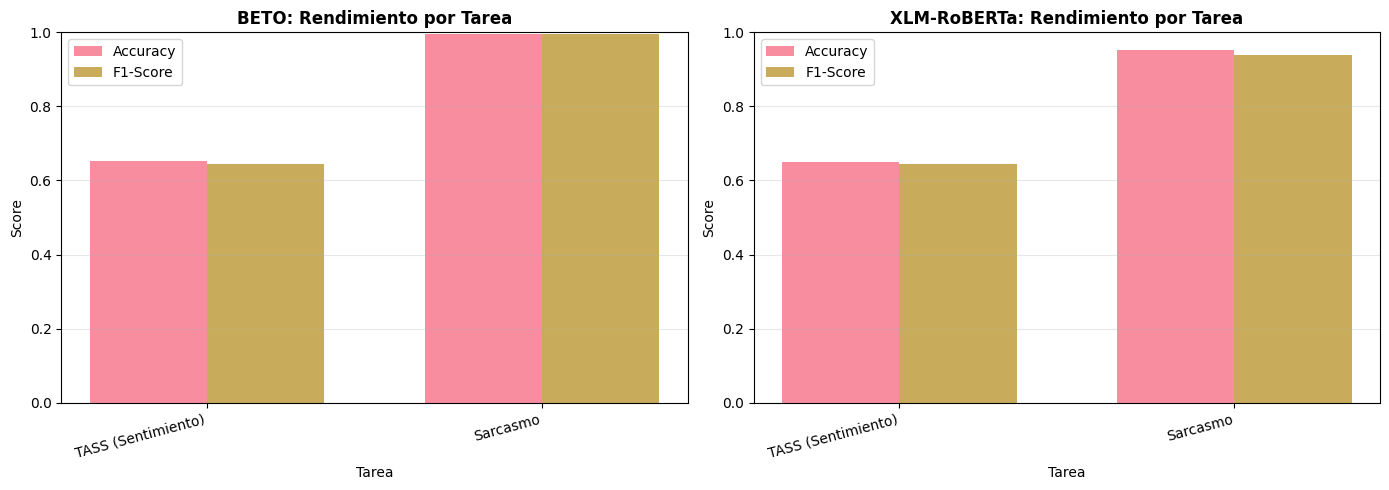

Gráfico guardado en: resultados/comparacion_por_modelo.png


In [4]:
# Comparar rendimiento de cada modelo entre tareas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BETO
beto_data = df_comparison[df_comparison['Modelo'] == 'BETO']
x = np.arange(len(beto_data))
width = 0.35

axes[0].bar(x - width/2, beto_data['Test_Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, beto_data['Test_F1'], width, label='F1-Score', alpha=0.8)
axes[0].set_xlabel('Tarea')
axes[0].set_ylabel('Score')
axes[0].set_title('BETO: Rendimiento por Tarea', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(beto_data['Tarea'], rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# XLM-RoBERTa
xlmr_data = df_comparison[df_comparison['Modelo'] == 'XLM-RoBERTa']
x = np.arange(len(xlmr_data))

axes[1].bar(x - width/2, xlmr_data['Test_Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x + width/2, xlmr_data['Test_F1'], width, label='F1-Score', alpha=0.8)
axes[1].set_xlabel('Tarea')
axes[1].set_ylabel('Score')
axes[1].set_title('XLM-RoBERTa: Rendimiento por Tarea', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlmr_data['Tarea'], rotation=15, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase3_comparativo/comparacion_por_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: resultados/fase3_comparativo/comparacion_por_modelo.png")

## 4. Análisis por Tarea

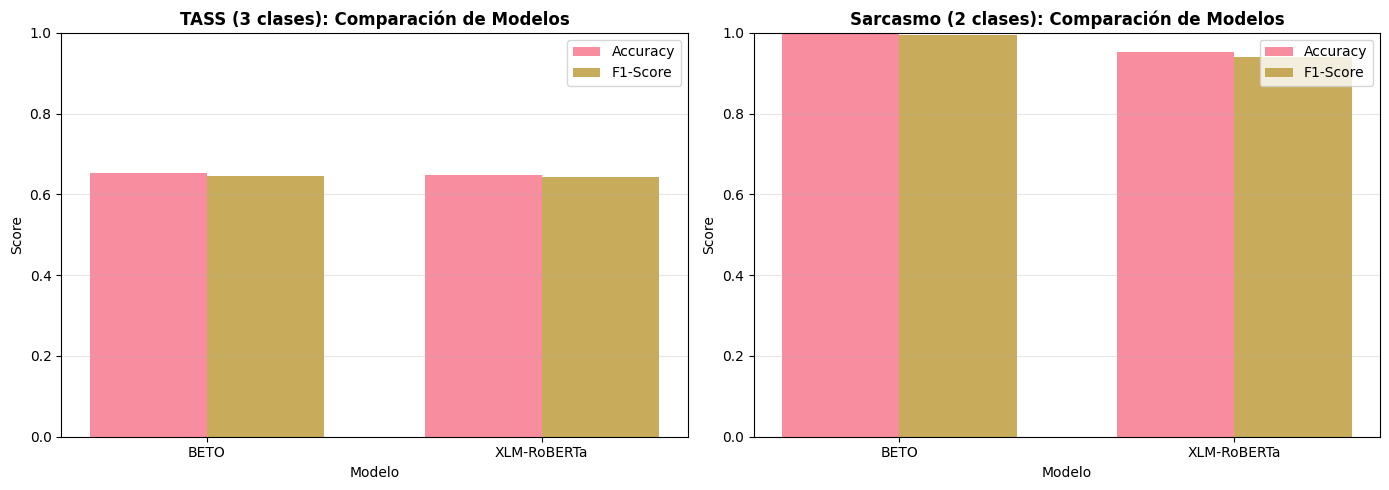

Gráfico guardado en: resultados/comparacion_por_tarea.png


In [5]:
# Comparar modelos dentro de cada tarea
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TASS
tass_data = df_comparison[df_comparison['Tarea'] == 'TASS (Sentimiento)']
x = np.arange(len(tass_data))
width = 0.35

axes[0].bar(x - width/2, tass_data['Test_Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, tass_data['Test_F1'], width, label='F1-Score', alpha=0.8)
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Score')
axes[0].set_title('TASS (3 clases): Comparación de Modelos', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tass_data['Modelo'])
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Sarcasmo
sarcasmo_data = df_comparison[df_comparison['Tarea'] == 'Sarcasmo']
x = np.arange(len(sarcasmo_data))

axes[1].bar(x - width/2, sarcasmo_data['Test_Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x + width/2, sarcasmo_data['Test_F1'], width, label='F1-Score', alpha=0.8)
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Score')
axes[1].set_title('Sarcasmo (2 clases): Comparación de Modelos', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sarcasmo_data['Modelo'])
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/fase3_comparativo/comparacion_por_tarea.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: resultados/fase3_comparativo/comparacion_por_tarea.png")

## 5. Impacto del Número de Clases

Análisis del Impacto del Número de Clases

BETO:
  TASS (3 clases) - F1: 0.6454
  Sarcasmo (2 clases) - F1: 0.9956
  Diferencia: +0.3502 (+54.25%)

XLM-RoBERTa:
  TASS (3 clases) - F1: 0.6441
  Sarcasmo (2 clases) - F1: 0.9391
  Diferencia: +0.2951 (+45.81%)



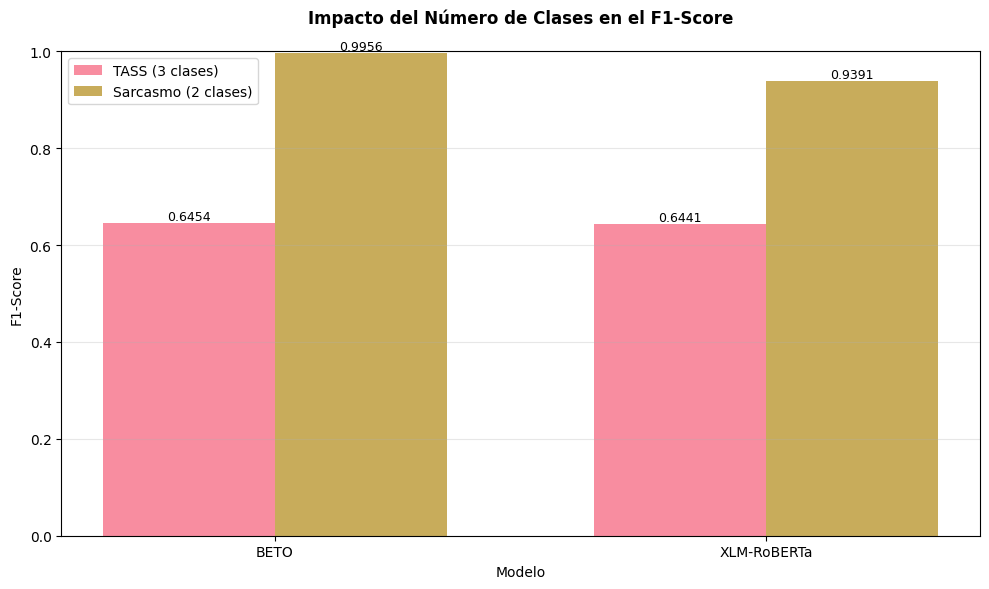

Gráfico guardado en: resultados/impacto_num_clases.png


In [4]:
# Calcular diferencias de rendimiento
print("Análisis del Impacto del Número de Clases")
print("="*70)

# BETO - Reutilizar variables ya definidas
beto_tass_f1 = tass_beto['test_f1']
beto_sarcasmo_f1 = sarcasmo_beto['test']['f1']
beto_diff = beto_sarcasmo_f1 - beto_tass_f1

print(f"\nBETO:")
print(f"  TASS (3 clases) - F1: {beto_tass_f1:.4f}")
print(f"  Sarcasmo (2 clases) - F1: {beto_sarcasmo_f1:.4f}")
print(f"  Diferencia: {beto_diff:+.4f} ({beto_diff/beto_tass_f1*100:+.2f}%)")

# XLM-RoBERTa - Reutilizar variables ya definidas
xlmr_tass_f1 = tass_xlmr['test_f1']
xlmr_sarcasmo_f1 = sarcasmo_xlmr['test']['f1']
xlmr_diff = xlmr_sarcasmo_f1 - xlmr_tass_f1

print(f"\nXLM-RoBERTa:")
print(f"  TASS (3 clases) - F1: {xlmr_tass_f1:.4f}")
print(f"  Sarcasmo (2 clases) - F1: {xlmr_sarcasmo_f1:.4f}")
print(f"  Diferencia: {xlmr_diff:+.4f} ({xlmr_diff/xlmr_tass_f1*100:+.2f}%)")

print("\n" + "="*70)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

models = ['BETO', 'XLM-RoBERTa']
tass_scores = [beto_tass_f1, xlmr_tass_f1]
sarcasmo_scores = [beto_sarcasmo_f1, xlmr_sarcasmo_f1]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, tass_scores, width, label='TASS (3 clases)', alpha=0.8)
bars2 = ax.bar(x + width/2, sarcasmo_scores, width, label='Sarcasmo (2 clases)', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_xlabel('Modelo')
ax.set_title('Impacto del Número de Clases en el F1-Score', fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../resultados/fase3_comparativo/impacto_num_clases.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: resultados/fase3_comparativo/impacto_num_clases.png")

## 6. Análisis de Tiempos de Entrenamiento

Análisis de Tiempos de Entrenamiento

Nota: Los tiempos de TASS no fueron guardados en los resultados.
Se muestran únicamente los tiempos de Sarcasmo.

SARCASMO (2 clases):
  BETO: 121.5s (2.02 min)
  XLM-RoBERTa: 235.5s (3.93 min)
  Diferencia: 114.0s
  XLM-RoBERTa es 1.94x más lento que BETO


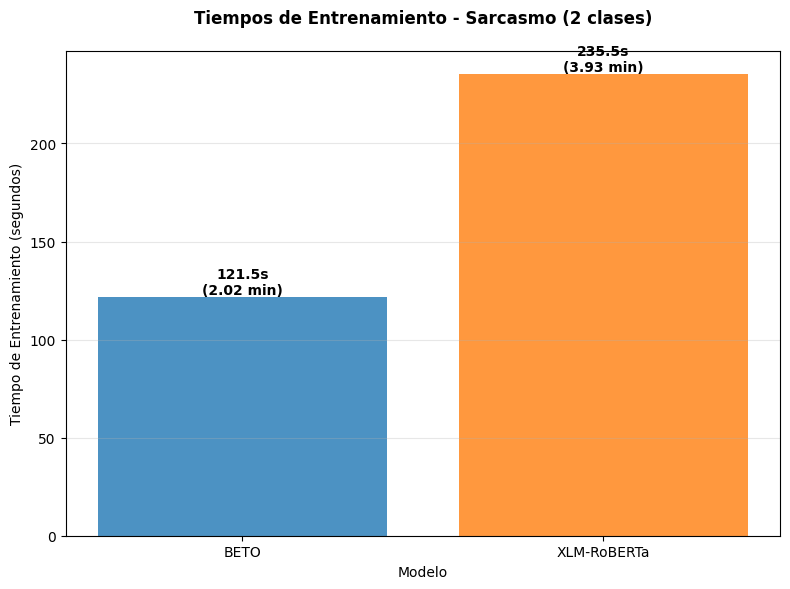


Gráfico guardado en: resultados/comparacion_tiempos.png


In [5]:
# Comparar tiempos de entrenamiento
# Nota: Los resultados de TASS no incluyen tiempos de entrenamiento guardados
# Solo mostramos los datos disponibles de Sarcasmo

print("Análisis de Tiempos de Entrenamiento")
print("="*70)
print("\nNota: Los tiempos de TASS no fueron guardados en los resultados.")
print("Se muestran únicamente los tiempos de Sarcasmo.\n")

print("SARCASMO (2 clases):")
print(f"  BETO: {sarcasmo_beto['train']['runtime']:.1f}s ({sarcasmo_beto['train']['runtime']/60:.2f} min)")
print(f"  XLM-RoBERTa: {sarcasmo_xlmr['train']['runtime']:.1f}s ({sarcasmo_xlmr['train']['runtime']/60:.2f} min)")
print(f"  Diferencia: {sarcasmo_xlmr['train']['runtime'] - sarcasmo_beto['train']['runtime']:.1f}s")
print(f"  XLM-RoBERTa es {sarcasmo_xlmr['train']['runtime']/sarcasmo_beto['train']['runtime']:.2f}x más lento que BETO")
print("="*70)

# Visualización solo con datos de Sarcasmo
fig, ax = plt.subplots(figsize=(8, 6))

models = ['BETO', 'XLM-RoBERTa']
sarcasmo_times = [
    sarcasmo_beto['train']['runtime'],
    sarcasmo_xlmr['train']['runtime']
]

x = np.arange(len(models))
bars = ax.bar(x, sarcasmo_times, alpha=0.8, color=['#1f77b4', '#ff7f0e'])

ax.set_ylabel('Tiempo de Entrenamiento (segundos)')
ax.set_xlabel('Modelo')
ax.set_title('Tiempos de Entrenamiento - Sarcasmo (2 clases)', fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}s\n({height/60:.2f} min)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../resultados/fase3_comparativo/comparacion_tiempos.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado en: resultados/fase3_comparativo/comparacion_tiempos.png")

## 7. Conclusiones del Análisis Comparativo

In [6]:
print("Conclusiones del Análisis Comparativo")
print("="*70)

# 1. Mejor modelo por tarea
print("\n1. MEJOR MODELO POR TAREA:")
best_tass = tass_comparison.loc[tass_comparison['Test F1'].idxmax(), 'Modelo']
best_sarcasmo = sarcasmo_comparison.loc[sarcasmo_comparison['Test F1'].idxmax(), 'Modelo']
print(f"   - TASS: {best_tass} (F1: {tass_comparison['Test F1'].max():.4f})")
print(f"   - Sarcasmo: {best_sarcasmo} (F1: {sarcasmo_comparison['Test F1'].max():.4f})")

# 2. Modelo más robusto
print("\n2. MODELO MÁS ROBUSTO (menor variación entre tareas):")
beto_variance = abs(beto_diff)
xlmr_variance = abs(xlmr_diff)
most_robust = "BETO" if beto_variance < xlmr_variance else "XLM-RoBERTa"
print(f"   - {most_robust}")
print(f"   - BETO variación: {beto_variance:.4f}")
print(f"   - XLM-RoBERTa variación: {xlmr_variance:.4f}")

# 3. Tarea más difícil
print("\n3. TAREA MÁS DIFÍCIL:")
avg_tass = (beto_tass_f1 + xlmr_tass_f1) / 2
avg_sarcasmo = (beto_sarcasmo_f1 + xlmr_sarcasmo_f1) / 2
harder_task = "TASS" if avg_tass < avg_sarcasmo else "Sarcasmo"
print(f"   - {harder_task}")
print(f"   - TASS F1 promedio: {avg_tass:.4f}")
print(f"   - Sarcasmo F1 promedio: {avg_sarcasmo:.4f}")

# 4. Impacto del número de clases
print("\n4. IMPACTO DEL NÚMERO DE CLASES:")
avg_improvement = (beto_diff + xlmr_diff) / 2
print(f"   - Reducir de 3 a 2 clases mejora el F1 promedio en: {avg_improvement:+.4f}")
if avg_improvement > 0:
    print("   - La clasificación binaria es más fácil que la multi-clase")
else:
    print("   - La complejidad de la tarea (sarcasmo) compensa la reducción de clases")

# 5. Eficiencia computacional
print("\n5. EFICIENCIA COMPUTACIONAL:")
print("   Nota: Solo datos de Sarcasmo disponibles")
sarcasmo_beto_time = sarcasmo_beto['train']['runtime']
sarcasmo_xlmr_time = sarcasmo_xlmr['train']['runtime']
faster_model = "BETO" if sarcasmo_beto_time < sarcasmo_xlmr_time else "XLM-RoBERTa"
print(f"   - Modelo más rápido en Sarcasmo: {faster_model}")
print(f"   - BETO: {sarcasmo_beto_time:.1f}s ({sarcasmo_beto_time/60:.2f} min)")
print(f"   - XLM-RoBERTa: {sarcasmo_xlmr_time:.1f}s ({sarcasmo_xlmr_time/60:.2f} min)")
print(f"   - XLM-RoBERTa es {sarcasmo_xlmr_time/sarcasmo_beto_time:.2f}x más lento")

print("\n" + "="*70)

Conclusiones del Análisis Comparativo

1. MEJOR MODELO POR TAREA:
   - TASS: dccuchile/bert-base-spanish-wwm-cased (F1: 0.6454)
   - Sarcasmo: BETO (F1: 0.9956)

2. MODELO MÁS ROBUSTO (menor variación entre tareas):
   - XLM-RoBERTa
   - BETO variación: 0.3502
   - XLM-RoBERTa variación: 0.2951

3. TAREA MÁS DIFÍCIL:
   - TASS
   - TASS F1 promedio: 0.6448
   - Sarcasmo F1 promedio: 0.9674

4. IMPACTO DEL NÚMERO DE CLASES:
   - Reducir de 3 a 2 clases mejora el F1 promedio en: +0.3226
   - La clasificación binaria es más fácil que la multi-clase

5. EFICIENCIA COMPUTACIONAL:
   Nota: Solo datos de Sarcasmo disponibles
   - Modelo más rápido en Sarcasmo: BETO
   - BETO: 121.5s (2.02 min)
   - XLM-RoBERTa: 235.5s (3.93 min)
   - XLM-RoBERTa es 1.94x más lento



## 8. Guardar Informe Final

In [7]:
# Crear informe consolidado
informe = {
    'comparacion_general': df_comparison.to_dict('records'),
    'mejor_modelo_por_tarea': {
        'tass': {
            'modelo': best_tass,
            'f1': float(tass_comparison['Test F1'].max())
        },
        'sarcasmo': {
            'modelo': best_sarcasmo,
            'f1': float(sarcasmo_comparison['Test F1'].max())
        }
    },
    'robustez': {
        'modelo_mas_robusto': most_robust,
        'beto_variacion': float(beto_variance),
        'xlmr_variacion': float(xlmr_variance)
    },
    'dificultad_tarea': {
        'tarea_mas_dificil': harder_task,
        'tass_f1_promedio': float(avg_tass),
        'sarcasmo_f1_promedio': float(avg_sarcasmo)
    },
    'impacto_num_clases': {
        'mejora_promedio_f1': float(avg_improvement),
        'beto_diferencia': float(beto_diff),
        'xlmr_diferencia': float(xlmr_diff)
    },
    'eficiencia': {
        'nota': 'Solo datos de Sarcasmo disponibles (TASS no guardó tiempos)',
        'modelo_mas_rapido': faster_model,
        'beto_tiempo_sarcasmo_s': float(sarcasmo_beto_time),
        'xlmr_tiempo_sarcasmo_s': float(sarcasmo_xlmr_time),
        'xlmr_vs_beto_ratio': float(sarcasmo_xlmr_time/sarcasmo_beto_time)
    }
}

# Guardar como JSON
with open('../resultados/fase3_comparativo/informe_comparativo.json', 'w', encoding='utf-8') as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print("Informe comparativo guardado en: resultados/fase3_comparativo/informe_comparativo.json")

# También guardar como texto
with open('../resultados/fase3_comparativo/informe_comparativo.txt', 'w', encoding='utf-8') as f:
    f.write("INFORME COMPARATIVO: TASS vs SARCASMO\n")
    f.write("="*70 + "\n\n")
    
    f.write("1. MEJOR MODELO POR TAREA:\n")
    f.write(f"   - TASS: {best_tass} (F1: {tass_comparison['Test F1'].max():.4f})\n")
    f.write(f"   - Sarcasmo: {best_sarcasmo} (F1: {sarcasmo_comparison['Test F1'].max():.4f})\n\n")
    
    f.write("2. MODELO MÁS ROBUSTO:\n")
    f.write(f"   - {most_robust}\n")
    f.write(f"   - BETO variación: {beto_variance:.4f}\n")
    f.write(f"   - XLM-RoBERTa variación: {xlmr_variance:.4f}\n\n")
    
    f.write("3. TAREA MÁS DIFÍCIL:\n")
    f.write(f"   - {harder_task}\n")
    f.write(f"   - TASS F1 promedio: {avg_tass:.4f}\n")
    f.write(f"   - Sarcasmo F1 promedio: {avg_sarcasmo:.4f}\n\n")
    
    f.write("4. IMPACTO DEL NÚMERO DE CLASES:\n")
    f.write(f"   - Mejora promedio al reducir de 3 a 2 clases: {avg_improvement:+.4f}\n\n")
    
    f.write("5. EFICIENCIA COMPUTACIONAL:\n")
    f.write("   Nota: Solo datos de Sarcasmo disponibles\n")
    f.write(f"   - Modelo más rápido en Sarcasmo: {faster_model}\n")
    f.write(f"   - BETO: {sarcasmo_beto_time:.1f}s ({sarcasmo_beto_time/60:.2f} min)\n")
    f.write(f"   - XLM-RoBERTa: {sarcasmo_xlmr_time:.1f}s ({sarcasmo_xlmr_time/60:.2f} min)\n")
    f.write(f"   - Ratio: XLM-RoBERTa es {sarcasmo_xlmr_time/sarcasmo_beto_time:.2f}x más lento\n")

print("Informe de texto guardado en: resultados/fase3_comparativo/informe_comparativo.txt")

Informe comparativo guardado en: resultados/informe_comparativo.json
Informe de texto guardado en: resultados/informe_comparativo.txt


## Resumen

### Archivos generados en `resultados/fase3_comparativo/`:
- `comparacion_general.csv`: Tabla con todos los resultados
- `comparacion_por_modelo.png`: Gráfico de rendimiento por modelo
- `comparacion_por_tarea.png`: Gráfico de rendimiento por tarea
- `impacto_num_clases.png`: Análisis del impacto del número de clases
- `comparacion_tiempos.png`: Comparación de tiempos de entrenamiento
- `informe_comparativo.json`: Informe completo en formato JSON
- `informe_comparativo.txt`: Informe completo en texto plano

### Próximos pasos:
- FASE 4: Entrenamiento BiLSTM para NER
- FASE 5: Fine-tuning LLM para NER